In [2]:
from openpiv import windef
from openpiv import tools, scaling, validation, filters, preprocess
import openpiv.pyprocess as process
from openpiv import pyprocess
import numpy as np
import pathlib
from time import time
import warnings
import tifffile as tif


import matplotlib.pyplot as plt
%matplotlib inline  

In [3]:
# SETTINGS

settings = windef.PIVSettings()

data_path = '/mnt/crunch/Clark/Larva/Larva 4.0 (7-5-26)/'
reference_stack_path = 'Rolling_Balled.tif'
deformed_stack_path = 'reference-rolling_Stack.tif'

# Change image settings to your own data
settings.filepath_images = pathlib.Path(data_path)
settings.save_path = pathlib.Path(data_path)
settings.save_folder_suffix = 'my_run'
settings.frame_pattern_a = 'frame_a.tif'   # Adjust to your naming
settings.frame_pattern_b = 'frame_b.tif'   # Adjust to your naming

settings.roi = 'full'
settings.dynamic_masking_method = 'None'

settings.deformation_method = 'symmetric'
settings.correlation_method = 'circular'
settings.normalized_correlation = False

# Multipass FFT settings
settings.num_iterations = 2
settings.windowsizes = (64, 32, 16)   # Coarse -> fine
settings.overlap = (32, 16, 8)        # 50% overlap at each pass
settings.subpixel_method = 'gaussian'
settings.interpolation_order = 3
settings.scaling_factor = 1
settings.dt = 1

settings.sig2noise_method = 'peak2peak'
settings.sig2noise_mask = 2

settings.validation_first_pass = True
settings.min_max_u_disp = (-60, 60)
settings.min_max_v_disp = (-60, 60)
settings.std_threshold = 8
settings.median_threshold = 4
settings.median_size = 1
settings.sig2noise_threshold = 1.0

settings.replace_vectors = True
settings.smoothn = True
settings.smoothn_p = 0.5
settings.filter_method = 'localmean'
settings.max_filter_iteration = 4
settings.filter_kernel_size = 2

settings.save_plot = False
settings.show_plot = False
settings.scale_plot = 200

running first_pass...
first_pass done


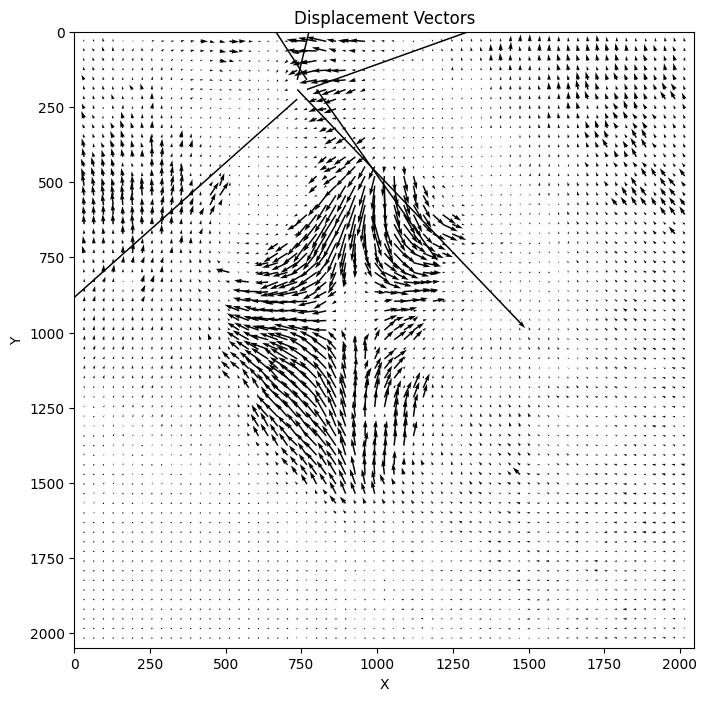

In [4]:
reference_stack = tif.imread('/mnt/crunch/Clark/Larva/Larva 4.0 (7-5-26)/reference-rolling_Stack.tif')
deformed_stack = tif.imread('/mnt/crunch/Clark/Larva/Larva 4.0 (7-5-26)/Rolling_Balled.tif')

frame_a = reference_stack[0].astype(np.int32)
frame_b = deformed_stack[0].astype(np.int32)

print("running first_pass...")
x, y, u, v, s2n = windef.first_pass(frame_a, frame_b, settings)
print("first_pass done")

u = np.ma.masked_array(u, mask=np.ma.nomask)
v = np.ma.masked_array(v, mask=np.ma.nomask)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.quiver(x, y, u, v)
plt.title("Displacement Vectors")
plt.xlabel("X")
plt.ylabel("Y")
plt.xlim(0, frame_a.shape[1])
plt.ylim(0, frame_a.shape[0])
plt.gca().invert_yaxis()  # Invert y-axis to match image coordinates
plt.show()

In [6]:
magnitude = np.sqrt(u**2 + v**2) 

flat_idx = np.argsort(magnitude.ravel())[::-1][:10] # Sort in descending order the ten largest magnitudes
rows, cols = np.unravel_index(flat_idx, magnitude.shape)

for r, c in zip(rows, cols):
    print(f"location (row={r}, col={c}) -> x={x[r,c]:.1f}, y={y[r,c]:.1f}, "
          f"u={u[r,c]:.2f}, v={v[r,c]:.2f}, magnitude={magnitude[r,c]:.2f}")

location (row=44, col=28) -> x=928.0, y=1440.0, u=nan, v=nan, magnitude=--
location (row=5, col=22) -> x=736.0, y=192.0, u=25.90, v=-27.11, magnitude=37.49
location (row=6, col=22) -> x=736.0, y=224.0, u=-27.57, v=-24.52, magnitude=36.90
location (row=4, col=23) -> x=768.0, y=160.0, u=-15.40, v=23.84, magnitude=28.38
location (row=5, col=23) -> x=768.0, y=192.0, u=25.78, v=9.22, magnitude=27.38
location (row=4, col=22) -> x=736.0, y=160.0, u=6.10, v=25.01, magnitude=25.74
location (row=5, col=24) -> x=800.0, y=192.0, u=13.74, v=-19.47, magnitude=23.83
location (row=17, col=29) -> x=960.0, y=576.0, u=-0.90, v=-3.57, magnitude=3.69
location (row=19, col=26) -> x=864.0, y=640.0, u=-1.69, v=-2.94, magnitude=3.39
location (row=18, col=26) -> x=864.0, y=608.0, u=-1.73, v=-2.78, magnitude=3.27


/tmp/ipykernel_818685/1719053032.py:7: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  print(f"location (row={r}, col={c}) -> x={x[r,c]:.1f}, y={y[r,c]:.1f}, "


In [ ]:
#* INITIALIZE

# Data 
reference_stack = tif.imread(data_path + reference_stack_path)
deformed_stack = tif.imread(data_path + deformed_stack_path)

# Results
results_u = []
results_v = []
results_x = None 
results_y = None 

# n_frames = reference_stack.shape[0]
n_frames = 10

# ------------------------------------------------------------------------------

# COMPUTATION

for current_frame in range(n_frames):
    # Set current slices
    frame_a = reference_stack[current_frame].astype(np.int32)
    frame_b = deformed_stack[current_frame].astype(np.int32)
    
    # Run the first pass
    x, y, u, v, sig2noise = windef.first_pass(frame_a, frame_b, settings)
    
    # Wrap as masked arrays (required by multipass_img_deform)
    u = np.ma.masked_array(u, mask=np.ma.nomask)
    v = np.ma.masked_array(v, mask=np.ma.nomask)
    
    # Run subsequent passes
    for iteration in range(1, settings.num_iterations):
        x, y, u, v, grid_mask, flags = windef.multipass_img_deform(
            frame_a, frame_b, iteration, x, y, u, v, settings
        )
        
    # Append results
    results_u.append(np.array(u))
    results_v.append(np.array(v))
    
    # x and y
    if results_x is None:
        results_x , results_y = x, y
    
    # Check progress every 50 frames
    if current_frame % 50 == 0:
        print(f"frame {current_frame}/{n_frames} done - u range {np.nanmin(u):.2f} to {np.nanmax(u):.2f}")
        
results_u = np.array(results_u)  # shape: (571, ny, nx)
results_v = np.array(results_v)

print("Done. results_u shape:", results_u.shape)